
  <img src="https://github.com/gefero/factor_data_tuto_NLP_SICSS/blob/main/imgs/logo_final_conjunto.png?raw=true" width="80%">


# Summer Institute in Computational Social Sciences - Buenos Aires 2026
# Taller: Procesamiento de Lenguaje Natural y polarización
# LLMs y uso de APIs

## Introducción
Este notebook ofrece una introducción a los Large Language Models (LLMs), centrándose en el modelo Gemini desarrollado por Google. Se exploran los conceptos básicos de los transformers, el mecanismo de self-attention, el prompt engineering y estrategias para interactuar con un LLM.

Como caso de aplicación, se retoma el dataset de reseñas de Amazon del Módulo 4 para clasificarlas en "positivo" o "negativo" utilizando Gemini. Se analizan los resultados y se realiza un análisis de errores para identificar las limitaciones del modelo.

El objetivo principal es comprender cómo funcionan los LLMs, sus potencialidades y cómo aplicarlos a tareas de procesamiento de lenguaje natural.

Pero antes tenemos que introducir una última cuestión. ¿Cómo interactuamos con un LLM?

## Cómo usar un LLM y qué es el prompt engineering
Ya mencionamos que un LLM es una herramienta sumamente útil que permite realizar diversas tareas basadas en texto: desde resúmenes y clasificaciones hasta generación de contenido y análisis de sentimientos. Sin embargo, su eficacia depende de cómo interactuemos con él. Aquí entra en juego el concepto de **prompt engineering**. Es la tarea que consiste en diseñar instrucciones claras y efectivas para maximizar la calidad de las respuestas del modelo.

Un LLM, como Gemini, está entrenado en vastos conjuntos de datos para reconocer patrones en el lenguaje. Aunque no "piensa" como un humano, puede generar respuestas coherentes y contextuales basadas en entradas específicas. El modelo procesa instrucciones llamadas *prompts*, que son preguntas, textos o comandos diseñados para guiar su comportamiento.

Por ejemplo, si queremos traducir una frase:
- Mal prompt: *"Traducción al inglés."*
- Buen prompt: *"Traduce la frase 'El perro juega en el parque' al inglés."*

Un buen prompt debe ser claro, estructurado y, cuando sea necesario, incluir ejemplos o contexto. Para usar en LLM tenemos que seguir algunos pasos:

1. **Definir la tarea**: Antes de usar un LLM, aclarar qué se busca lograr: ¿Resumir? ¿Clasificar? ¿Analizar sentimientos? Esto determinará cómo diseñar el prompt.

2. **Diseñar el prompt**: Asegurarse de que la instrucción:
   - Sea específica.
   - Proporcione contexto relevante.
   - Indique el formato esperado de la respuesta.

3. **Usar la herramienta adecuada**:
   - *Interfaz directa*: Plataformas como Gemini permiten interactuar con el modelo escribiendo prompts directamente.
   - *API programática*: Si es necesario integrar el LLM en proyectos, es poisble usar lenguajes como Python o R para enviar solicitudes al modelo.

4. **Revisar e iterar**: Evaluar las respuestas y ajustar el prompt según sea necesario. La iteración es clave para obtener resultados óptimos.

### Estrategias de prompt engineering
Hay varias formas de diseñar un prompt.

1. **Zero-shot prompting**
Pide al modelo realizar una tarea sin ningún ejemplo previo. Es útil para tareas simples. Por ejemplo,
```
Traduce al inglés: 'El perro juega en el parque
```

2. **One-shot prompting**
Proporciona un ejemplo para guiar al modelo.
 ```
 Genera una pregunta para una encuesta sobre satisfacción laboral.
 Ejemplo: '¿Qué tan satisfecho está con su horario de trabajo?'
 Nueva pregunta:
 ```

3. **Few-shot prompting**
Incluye varios ejemplos para ayudar al modelo a generalizar mejor.
```
Clasifica las siguientes frases según la emoción:
- "Estoy feliz hoy." → Alegría
- "Estoy cansado." → Tristeza
- "Estoy ansioso por mañana." → Ansiedad

Frase: "No puedo creer que gané la lotería." → Emoción:
 ```

4. **Chain-of-thought prompting**
Solicita que el modelo muestre su razonamiento paso a paso antes de dar una respuesta final.
```
Pregunta: Si Juan tiene 3 manzanas y compra 5 más, ¿cuántas tiene en total? Razonamiento:

1. Juan tiene 3 manzanas.
2. Compra 5 más, así que ahora tiene 3 + 5.

Respuesta final:
```

5. **Contextual prompting**
Proporciona al modelo un contexto para que las respuestas sean más relevantes.
```
 Eres un experto en marketing. Crea un eslogan para una marca de café sostenible.
```

6. **Instruction-based prompting**
Diseña el prompt como una instrucción directa y detallada.
```
Resume el siguiente texto en tres frases que incluyan las ideas principales: [texto].
```

Pese a lo bien que funcionan los LLMs es necesario tener en cuenta algunas limitaciones a los fines de evitar malos entendidos.

En primer lugar, más allá del marketing alrededor de estas herramientas es importante mencionar que **no razonan como humanos**. Se limitan a generar respuestas basadas en patrones estadísticos, de allí el término ["loros aleatorios"](https://dl.acm.org/doi/10.1145/3442188.3445922). ¿Esto es un problema? Depende. Si los queremos usar para resolver tareas concretas como las que hemos mencionado hasta aquí como la que vamos a atacar en breve, no. En otros contextos, puede ser.

A su vez, los LLMS (al igual que cualquier otro algoritmo, modelo o método que se basa en datos de entrada y trata de aprender patrones subyacentes) tienen **sesgos**. Hay una amplísima bibliografía  Pueden reflejar sesgos presentes en los datos de entrenamiento. Esto hace que sea necesario tener cuidado al momento de seleccionar la tarea que vamos a solicitarle. Por otro lado, tienen **memoria limitada**, no recuerdan interacciones previas a menos que se incluyan en el contexto.

# Gemini, el modelo que vamos a usar
Google DeepMind ha desarrollado Gemini, una familia de modelos de inteligencia artificial con capacidades multimodales. Esto implica que Gemini puede procesar y comprender diversos tipos de información, como texto e imágenes.

![](../imgs/logo.jpeg)

Gemini es un modelo de lenguaje grande (LLM) que utiliza una arquitectura de red neuronal Transformer. Esta arquitectura le permite procesar información de manera eficiente y comprender las relaciones entre las palabras en un texto.

Gemini fue entrenado por Google utilizando una gran cantidad de datos de texto y código. Este proceso de entrenamiento implica ajustar los parámetros de la red neuronal para que pueda predecir la siguiente palabra o token en una secuencia. El entrenamiento se realiza en varias etapas, con conjuntos de datos cada vez más grandes y complejos. Esto permite a Gemini aprender patrones y relaciones en el lenguaje, mejorando su capacidad para comprender y generar texto.

# El caso de aplicación
Vamos a volver sobre el dataset de reseñas de Amazon de la semana pasada y  a retomar la tarea de clasificación de las mismas en "positivo" o "negativo". En realidad, vamos a trabajar sobre una muestra de unas 1200 reseñas, dado que la API de Gemini solamente permite un número limitado de requests gratis en un día.

Primero vamos a instalar la librería que nos va a servir de interface para trabajar con Gemini. La misma la pueden encontrar en https://github.com/google-gemini/generative-ai-python. Es la librería oficial de Google para interactuar con la API de Gemini en Python. Ejecutando la celda siguiente pueden instalar el paquere.

In [ ]:
!pip install google-generativeai

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import re
import time
#import google.generativeai as genai
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, precision_recall_fscore_support, confusion_matrix


## Primer paso, autenticación
Como ya hemos visto a lo largo de este curso, las APIs actúan como intermediarios que permiten la comunicación e intercambio de datos entre diferentes sistemas. Por este motivo, la autenticación es crucial para asegurar la seguridad y controlar el acceso a la información.

Para usar `google-generativeai`, debemos autenticarnos con una clave personal que debemos crear en https://aistudio.google.com/app/apikey. La función `genai.configure` en `google-generativeai` nos permite configurar esta clave.

In [ ]:
from google.colab import ai
#response = ai.generate_text("What is the capital of France?")
#print(response)

In [ ]:
ai.list_models()

['google/gemini-3.1-pro-preview', 'google/gemini-3.5-flash']

## Segundo paso, diseño del prompt
Perfecto. Vamos ahora a diseñar un prompt simple para nuestra tarea.

In [ ]:
# Diseño del prompt
prompt = """A continuación vas a recibir un texto de una reseña de compra online.
Quisiera que la clasifiques positiva o negativa usando las siguientes categorías:

- Positiva: la reseña es positiva
- Negativa: la reseña es negativa

Quisiera que expliques paso a paso tu razonamiento.

La salida debería tener el siguiente formato:

clasif: seguido de la clasificación | expl: seguido de la explicación

Texto:
"""

Cargamos el dataset. En realidad, vamos a cargar unos 1259 datos del dataset original para hacer esta prueba.

In [ ]:
# Cargamos el dataset completo
data_path = 'https://raw.githubusercontent.com/gefero/ecyt_lcd_intro_nlp/main/U4/data/amazon_reviews_train.csv'
reviews = pd.read_csv(data_path)
reviews = reviews.drop('product_category', axis=1)
# Transformamos 'stars' de números a textos
reviews['stars'] = (reviews['stars'].astype(str) + ' stars').replace('1 stars', '1 star')

# Y transformamos la columna en una variable categórica
reviews['stars'] = reviews['stars'].astype('category')

# Generamos una variable en tres categorías
sentiment_map = {
    '1 star': 'Negative',
    '2 stars': 'Negative',
    '3 stars': 'Neutral',
    '4 stars': 'Positive',
    '5 stars': 'Positive'
}
reviews['sentiment_label'] = reviews['stars'].map(sentiment_map)

# Filtramos las "Neutral" y transformamos 'sentiment_label' en categórica
reviews = reviews[reviews['sentiment_label'] != 'Neutral']
reviews['sentiment_label'] = reviews['sentiment_label'].astype('category')

# Extraemos una muestra de 12000 casos (6000 por categoria)
reviews = reviews.groupby("sentiment_label").sample(n=6000, random_state=78)

# Función para preprocesar
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Replace punctuation
    text = re.sub(r'[^A-zÀ-ÿ ]', ' ', text)
    # Replace numbers with 'DIGITO'
    text = re.sub(r'\d+', 'DIGITO', text)
    # Replace non-ASCII characters
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')
    return text

reviews['review_body'] = reviews['review_body'].apply(preprocess_text)

# Define target variable y
y = reviews['sentiment_label']
X = reviews[['review_id', 'review_body']]

# Train-test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.2,
    random_state=85,
    stratify=y
)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    shuffle=True,
    test_size=0.25,
    random_state=45,
    stratify=y_temp
)


/tmp/ipykernel_1736/3113188331.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reviews = reviews.groupby("sentiment_label").sample(n=6000, random_state=78)


In [ ]:
X_test

,review_id,review_body
129389,es_0884933,encaja perfectamente y es de calidad pero el ...
32401,es_0570751,es muy malo no pega nada bien a la minima vi...
38687,es_0948475,la ubicacion no es correcta
180129,es_0242768,tres al precio de una tres colores lastima d...
35270,es_0901699,no lo recomiendo lo compre pensando que era e...
...,...,...
43968,es_0233375,lo tuve que devolver porque era muy pequeno pa...
125730,es_0060990,mismo que en la foto aunque llego ligeramente ...
159101,es_0253494,me gusto el formato y lo ordenado del contenid...
153491,es_0263810,demasiado caro para lo que es algunas cuentas...


## Tercer paso, hacemos las request, llamamos al LLM
Y vamos a iterar por cada una de las filas del dataset y para cada fila, vamos a hacer una request a la API de Gemini con dos inputs:

1. el `prompt` que diseñamos más arriba
2. el texto de la reseña (`review_body`)

In [ ]:
# Configurar el modelo
model = genai.GenerativeModel('models/gemini-2.0-flash-lite')

In [ ]:
rtas = {}
total_req = len(X_test)
it = 0
for index, col in X_test.iterrows():
  it = it + 1
  time.sleep(4.5)  # Pausa
  print(f"Procesando comentario {it} de {total_req}")

  try:
        # Generar respuesta usando el modelo
        response = model.generate_content(prompt + col['review_body'])
        rta = response.text  # Obtener el texto
        print(rta)
        rtas[col['review_id']] = rta

  except Exception as e:
      print(f"Error processing review {id}: {str(e)}")
      rtas[col['review_id']] = "Error"

  if it % 10 == 0:
    pd.DataFrame.from_dict(rtas, orient='index', columns=['resp']).to_csv('./rtas.csv')

Procesando comentario 1 de 2400


Error processing review <built-in function id>: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash-lite
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash-lite
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash-lite
Please retry in 59.968565866s.
Procesando comentario 2 de 2400


Error processing review <built-in function id>: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash-lite
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash-lite
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash-lite
Please retry in 54.921474754s.


KeyboardInterrupt: 

El código anterior itera sobre el dataframe de reseñas de productos (almacenadas en `df_list`), hace la consulta a la API de Gemini, usando el `prompt`

Vamos paso a paso:

1. **Inicialización:** Se crea un diccionario vacío llamado rtas que almacenará las respuestas de Gemini.

2. **Bucle for:** Se itera a través de las dos primeras reseñas en df_list.

3. **Extracción de ID:** En cada iteración, se extrae el ID de la reseña actual (review_id) y se almacena en la variable idx.

4. **Pausa:** Se introduce una pausa de 4.5 segundos utilizando time.sleep(4.5) para evitar sobrecargar la API de Gemini.

5. **Mensaje de progreso:** Se imprime un mensaje en la consola indicando el progreso del procesamiento: "Procesando comentario [i] de [total de reseñas]".

6. **Llamada a Gemini:** Se utiliza la función model.generate_content() para enviar una consulta al modelo de lenguaje.
  - La consulta se construye concatenando un prompt predefinido con el texto de la reseña actual (df_list['review_body'].iloc[i]).
  - El resultado de la consulta (la respuesta de Gemini) se almacena en la variable rta.

7. **Impresión de la respuesta:** Se imprime la respuesta de Gemini en la consola utilizando print(rta).

8. **Almacenamiento de la respuesta:** La respuesta de Gemini (rta) se almacena en el diccionario rtas, utilizando el ID de la reseña como clave.

9. **Fin del bucle:** El proceso se repite para las dos primeras reseñas.

Para ganar tiempo, ya hemos corrido las consultas al LLM. Vamos a cargar los resultados.

Por algún motivo, estos días la API de Gemini está muy restrictiva para los usuarios gratis, por eso vamos a usar [una librería bastante útil](https://medium.com/google-colab/introducing-google-colab-ai-the-easiest-way-to-use-generative-ai-in-colab-no-setup-required-eee01230e0cf) que tiene Colab y que, por ahora, es gratis:

In [ ]:
from google.colab import ai
model = 'google/gemini-2.5-flash-lite'
ai.list_models()

['google/gemini-3.1-pro-preview', 'google/gemini-3.5-flash']

In [ ]:
%%time
rtas = {}
total_req = len(X_test)
it = 0
for index, col in X_test.iterrows():
  it = it + 1
  time.sleep(4.5)  # Pausa

  try:
        # Generar respuesta usando el modelo
        rta = ai.generate_text(prompt + col['review_body'], model_name=model)
        rtas[col['review_id']] = rta

  except Exception as e:
      print(f"Error processing review {id}: {str(e)}")
      rtas[col['review_id']] = "Error"

  if it % 10 == 0:
    print(f"Procesando comentario {it} de {total_req}")
    print(rta)
    pd.DataFrame.from_dict(rtas, orient='index', columns=['resp']).to_csv('./rtas.csv')

Procesando comentario 10 de 2400
clasif: Negativa | expl: La reseña utiliza la palabra "pequeños" en un contexto negativo, sugiriendo que el producto no cumple con las expectativas de ser "profesional", lo cual implica una insatisfacción con el tamaño o la calidad.
Procesando comentario 20 de 2400
clasif: Positiva | expl: La reseña indica que el producto, aunque no sea un recambio original, cumple su función de manera perfecta. La frase "hace su funcion perfectamente" es un claro indicador de satisfacción y buen desempeño del producto, lo que la clasifica como positiva.
Procesando comentario 30 de 2400
clasif: Negativa | expl: La reseña comienza con una expresión clara de decepción ("me ha decepcionado"). Aunque reconoce que la autora es querida y que las expectativas pudieron ser altas, la palabra clave "decepcionado" define el tono general de la reseña como negativo. El hecho de que se termine rápido ("en una horita lo tienes acabado") puede interpretarse como que falta profundidad o

KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download('rtas.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Obviamente, ya habíamos clasificado antes todo el test set, así que lo cargamos:

In [ ]:
rtas_test_df = pd.read_csv("https://raw.githubusercontent.com/gefero/ecyt_lcd_intro_nlp/main/U5/data/test_set_amazon_reviews_rtas.csv")
rtas_test_df.columns = ['review_id', 'resp']
rtas_test_df.head()

,review_id,resp
0,es_0884933,clasif: Negativa | expl: La reseña presenta un...
1,es_0570751,clasif: Negativa | expl: La reseña utiliza tér...
2,es_0948475,clasif: Negativa | expl: La reseña indica un p...
3,es_0242768,clasif: Positiva | expl: El usuario expresa un...
4,es_0901699,clasif: Negativa | expl: La reseña expresa ins...


## Cuarto paso, formateando los resultados
Como habrán notado en la salida anterior, las respuestas del modelo son básicamente un largo `string`. Toda la respuesta (la etiqueta y la explicación) están juntas. No obstante, hemos diseñado el prompt para que aparezca con algunos delimitadores que nos hagan más fácil la extracció de la información. Para ello vamos a definir dos funciones:

In [ ]:
def parse_clasif(string):
    clasif = re.search(r'(?<=clasif: ).*?(?= \|)', string)
    return clasif.group() if clasif else None

La función `parse_clasif` en Python está diseñada para extraer la clasificación de una reseña de un texto, específicamente la parte que indica si la reseña es "Positiva" o "Negativa".

El objetivo principal de la función es identificar y extraer la clasificación ("Positiva" o "Negativa") de una cadena de texto que contiene la respuesta de un modelo de lenguaje.

¿Cómo funciona?
**1. Entrada:** Recibe una cadena de texto (`string`) que se espera que contenga la clasificación de una reseña en un formato específico, por ejemplo: `clasif: Positiva | expl: El usuario expresó satisfacción con el producto`.

**2. `re.search`:** Utiliza la función re.search del módulo re de Python para buscar y extraer la parte de la cadena que coincide con un patrón específico.

**3. Patrón:** El patrón utilizado es una expresión regular: `(?<=clasif: ).*?(?= \|)`. Vamos a desglosarlo:
    
  - `(?<=clasif: )`: Esta parte busca la cadena "clasif: " y asegura que la coincidencia comience justo después de ella. Se conoce como una "aserción lookbehind positiva".
  - `.*?`: Esta parte coincide con cualquier caracter (`.`) cero o más veces (`*`), pero de la manera más perezosa posible (`?`). Esto significa que intentará encontrar la coincidencia más corta posible.
  - `(?= \|)`: Esta parte busca el caracter "|" precedido por un espacio y asegura que la coincidencia termine justo antes de él. Se conoce como una "aserción lookahead positiva".

**4. Extracción:** `re.search` devuelve un objeto Match si encuentra una coincidencia. Usando el método `.group()` extraemos la parte de la cadena que coincide con el patrón completo. En este caso, sería "Positiva" o "Negativa".

**5. Retorno:** La función devuelve el valor extraído si se encuentra una coincidencia, o None si no se encuentra ninguna coincidencia. Esto se maneja con una expresión condicional `clasif.group() if clasif else None`.

In [ ]:
def parse_expl(string):
    expl = re.search(r'(?<=expl).*', string)
    if expl:
        # Eliminar los caracteres ':' y "'" y hacer trim
        cleaned_expl = re.sub(r':|\'', '', expl.group()).strip()
        return cleaned_expl
    return None

Ahora bien, `parse_expl` está diseñada para extraer la explicación de una reseña de un texto, específicamente la parte que explica por qué la reseña fue clasificada como "Positiva" o "Negativa".

**1. Entrada:** Recibe una cadena de texto (string) que se espera que contenga la explicación de una reseña en un formato específico, por ejemplo: "clasif: Positiva | expl: El usuario expresó satisfacción con el producto".

**2. `re.search`:** Similar a `parse_clasif`, utiliza re.search del módulo re de Python para buscar y extraer la parte de la cadena que coincide con un patrón específico.

**3. Patrón:** El patrón utilizado es `(?<=expl).*`.
  - `(?<=expl)`: Es una aserción "lookbehind positiva" que busca la cadena "expl" y asegura que la coincidencia comience justo después de ella.
  - `.*`: Esta parte coincide con cualquier caracter (`.`) cero o más veces (`*`), lo que significa que selecciona todo el texto después de "expl".

**4. `re.sub`:** Se utiliza para limpiar la explicación extraída. Reemplaza todos los caracteres ":" y "'" por una cadena vacía mediante la expresión regular `r':|\''. Esto ayuda a eliminar cualquier rastro del formato original.

**5. `strip()`:** Se aplica para eliminar cualquier espacio en blanco al principio y al final de la explicación, asegurando que la salida esté limpia. Este es el equivalente en Python a la función `str_trim` de R.

**6. Retorno:** La función devuelve la explicación extraída y limpia si se encuentra una coincidencia, o None si no se encuentra ninguna coincidencia. Esto representa el razonamiento detrás de la clasificación de la reseña.

**Ejemplo:**
Si la entrada es "clasif: Positiva | expl: El usuario expresó satisfacción con el producto.", la función parse_expl devolverá "El usuario expresó satisfacción con el producto".

In [ ]:
# Aplicamos las funciones previamente definidas
rtas_test_df['llm_expl'] = rtas_test_df['resp'].apply(parse_expl)
rtas_test_df['llm_stars'] = rtas_test_df['resp'].apply(parse_clasif)

# Mergeamos el dataset
rtas_test_df = rtas_test_df.merge(reviews[["review_id", "review_body", "sentiment_label"]], on='review_id', how='inner')

In [ ]:
rtas_test_df

,review_id,resp,llm_expl,llm_stars,review_body,sentiment_label
0,es_0884933,clasif: Negativa | expl: La reseña presenta un...,La reseña presenta un sentimiento mixto. Si bi...,Negativa,encaja perfectamente y es de calidad pero el ...,Positive
1,es_0570751,clasif: Negativa | expl: La reseña utiliza tér...,La reseña utiliza términos explícitamente nega...,Negativa,es muy malo no pega nada bien a la minima vi...,Negative
2,es_0948475,clasif: Negativa | expl: La reseña indica un p...,La reseña indica un problema específico con el...,Negativa,la ubicacion no es correcta,Negative
3,es_0242768,clasif: Positiva | expl: El usuario expresa un...,El usuario expresa una satisfacción general co...,Positiva,tres al precio de una tres colores lastima d...,Positive
4,es_0901699,clasif: Negativa | expl: La reseña expresa ins...,La reseña expresa insatisfacción con el produc...,Negativa,no lo recomiendo lo compre pensando que era e...,Negative
...,...,...,...,...,...,...
2395,es_0233375,clasif: Negativa | expl: La reseña indica que ...,La reseña indica que el producto tuvo que ser ...,Negativa,lo tuve que devolver porque era muy pequeno pa...,Negative
2396,es_0060990,clasif: Positiva | expl: El usuario menciona q...,"El usuario menciona que el producto es ""mismo ...",Positiva,mismo que en la foto aunque llego ligeramente ...,Positive
2397,es_0253494,clasif: Negativa | expl: La reseña comienza co...,La reseña comienza con un comentario positivo ...,Negativa,me gusto el formato y lo ordenado del contenid...,Positive
2398,es_0263810,clasif: Negativa | expl: La reseña indica que ...,"La reseña indica que el producto es ""demasiado...",Negativa,demasiado caro para lo que es algunas cuentas...,Positive


- `llm_expl = rtas_df['resp'].apply(parse_expl)`: Crea una nueva columna llamada "llm_expl" aplicando la función parse_expl a la columna "resp". Esto extrae la explicación de la reseña del texto de la respuesta.
- `llm_stars = rtas_df['resp'].apply(parse_clasif)`: Crea otra nueva columna llamada "llm_stars" aplicando la función parse_clasif a la columna "resp". Esto extrae la clasificación de la reseña (Positiva o Negativa).

In [ ]:
# Normalización y conversión en categoría
rtas_test_df['sentiment_label'] = rtas_test_df['sentiment_label'].replace('Positive', 'Positiva')
rtas_test_df['sentiment_label'] = rtas_test_df['sentiment_label'].replace('Negative', 'Negativa')

# Verificamos resultados
print(rtas_test_df.shape)

print(rtas_test_df[['review_id', 'sentiment_label', 'llm_stars']].head())

(2400, 6)
    review_id sentiment_label llm_stars
0  es_0884933        Positiva  Negativa
1  es_0570751        Negativa  Negativa
2  es_0948475        Negativa  Negativa
3  es_0242768        Positiva  Positiva
4  es_0901699        Negativa  Negativa


/tmp/ipykernel_1282/668766472.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  rtas_test_df['sentiment_label'] = rtas_test_df['sentiment_label'].replace('Positive', 'Positiva')
/tmp/ipykernel_1282/668766472.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  rtas_test_df['sentiment_label'] = rtas_test_df['sentiment_label'].replace('Negative', 'Negativa')


Este código realiza dos operaciones principales para asegurar la consistencia y la revisión inicial de los datos:

1.  **Normalización de etiquetas:**
    *   Las líneas `rtas_test_df['sentiment_label'] = rtas_test_df['sentiment_label'].replace('Positive', 'Positiva')` y `rtas_test_df['sentiment_label'] = rtas_test_df['sentiment_label'].replace('Negative', 'Negativa')` se encargan de unificar la terminología. Reemplazan las etiquetas 'Positive' por 'Positiva' y 'Negative' por 'Negativa' en la columna `sentiment_label`. Esto es crucial para que coincidan con el formato utilizado en la columna `llm_stars`, que contiene las clasificaciones generadas por el LLM.

2.  **Verificación de resultados:**
    *   `print(rtas_test_df.shape)`: Muestra las dimensiones (número de filas y columnas) del DataFrame `rtas_test_df` una vez aplicadas las modificaciones. Esto permite confirmar que el tamaño del DataFrame sigue siendo el esperado.
    *   `print(rtas_test_df[['review_id', 'sentiment_label', 'llm_stars']].head())`: Imprime las primeras cinco filas de las columnas `review_id`, `sentiment_label` (la etiqueta original ya normalizada) y `llm_stars` (la clasificación predicha por el LLM). Esta visualización rápida es muy útil para comparar directamente las etiquetas reales con las predicciones del modelo.

## Resultados
Veamos ahora, entonces, cómo funcionó nuestro modelo. Vamos a calcular las métricas habituales.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
print(classification_report(rtas_test_df["sentiment_label"], rtas_test_df["llm_stars"]))

              precision    recall  f1-score   support

    Negativa       0.90      0.98      0.94      1200
      Neutra       0.00      0.00      0.00         0
    Positiva       0.98      0.90      0.93      1200

    accuracy                           0.94      2400
   macro avg       0.63      0.62      0.62      2400
weighted avg       0.94      0.94      0.94      2400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(prompt)

A continuación vas a recibir un texto de una reseña de compra online.
Quisiera que la clasifiques positiva o negativa usando las siguientes categorías:

- Positiva: la reseña es positiva
- Negativa: la reseña es negativa

Quisiera que expliques paso a paso tu razonamiento.

La salida debería tener el siguiente formato:

clasif: seguido de la clasificación | expl: seguido de la explicación

Texto:



Notar cómo aparece un error. Aparentemente el LLM hizo una predicción de una reseña como neutra. Vamos a filtarla:

In [ ]:
neutra = rtas_test_df[rtas_test_df["llm_stars"] == "Neutra"]
print(neutra["review_body"])

1808    no opino pues todavia no lo he recibido
Name: review_body, dtype: object


Es interesante observar que el LLM clasificó esta reseña específica como "Neutra", a pesar de que el `prompt` original solo instruía al modelo a clasificar las reseñas como "Positiva" o "Negativa".

Esto resalta una característica importante de los LLMs: aunque se les den instrucciones específicas, a veces pueden generar respuestas que van más allá de las categorías o formatos estrictamente definidos en el prompt. En este caso, el modelo identificó un matiz en la reseña ("no opino pues todavia no lo he recibido") que, desde su perspectiva, no encajaba claramente en "Positiva" ni en "Negativa", y por lo tanto, eligió una categoría intermedia implícita como "Neutra".

Este comportamiento puede ser una señal de la capacidad del modelo para interpretar el lenguaje de una manera más flexible, pero también indica que el `prompt` podría beneficiarse de una formulación más restrictiva si se desea limitar estrictamente las categorías de salida a las especificadas (Positiva/Negativa). Para nuestro análisis de métricas, esto causa un problema ya que 'Neutra' no existe en las etiquetas reales, generando la `UndefinedMetricWarning` que vimos anteriormente.



### Ejercicio
Pensar en 5 minutos cómo podemos mejorar esto a nivel prompt

In [ ]:
prompt2 = """
A continuación vas a recibir un texto de una reseña de compra online.
Quisiera que la clasifiques positiva o negativa usando las siguientes categorías:

- Positiva: la reseña es positiva
- Negativa: la reseña es negativa

Utilizá solamente estas dos categorías. No uses otra.

Quisiera que expliques paso a paso tu razonamiento.

La salida debería tener el siguiente formato:

clasif: seguido de la clasificación | expl: seguido de la explicación

Texto:
"""
print(ai.generate_text(prompt2 + "no opino pues todavia no lo he recibido", model_name=model))

clasif: Negativa | expl: La reseña indica que el usuario aún no ha recibido el producto, lo que implica que no puede emitir una opinión positiva ni negativa sobre él. Al no haber una experiencia de uso, no hay elementos para considerarla positiva.


Para solucionar el problema de la categoría 'Neutra' y la advertencia de métricas, vamos a filtrar el DataFrame `rtas_test_df` para incluir solo las predicciones 'Positiva' y 'Negativa' antes de calcular el informe de clasificación. Esto asegura que solo las clases relevantes sean consideradas en la evaluación.

In [ ]:
# Filtramos el DataFrame para excluir las predicciones 'Neutra'
filtered_rtas_test_df = rtas_test_df[rtas_test_df['llm_stars'].isin(['Positiva', 'Negativa'])]

print("Informe de Clasificación después de filtrar 'Neutra':")
print(classification_report(filtered_rtas_test_df["sentiment_label"], filtered_rtas_test_df["llm_stars"]))

Informe de Clasificación después de filtrar 'Neutra':
              precision    recall  f1-score   support

    Negativa       0.90      0.98      0.94      1199
    Positiva       0.98      0.90      0.93      1200

    accuracy                           0.94      2399
   macro avg       0.94      0.94      0.94      2399
weighted avg       0.94      0.94      0.94      2399



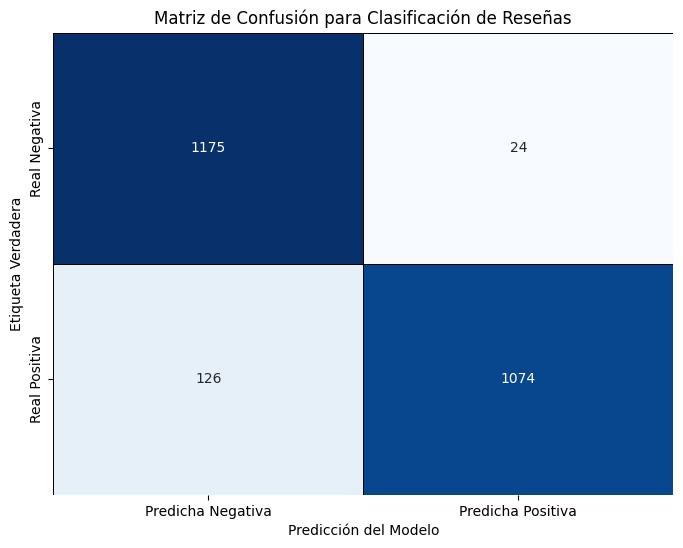

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las etiquetas verdaderas y predichas del DataFrame filtrado
y_true_filtered = filtered_rtas_test_df["sentiment_label"]
y_pred_filtered = filtered_rtas_test_df["llm_stars"]

# Calcular la matriz de confusión
cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=['Negativa', 'Positiva'])

# Crear un DataFrame para la matriz de confusión con etiquetas claras
cm_df = pd.DataFrame(
    cm,
    index=['Real Negativa', 'Real Positiva'],
    columns=['Predicha Negativa', 'Predicha Positiva']
)

# Visualizar la matriz de confusión con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, linecolor='black')
plt.title('Matriz de Confusión para Clasificación de Reseñas')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Verdadera')
plt.show()

Al analizar el rendimiento de nuestro modelo LLM en la clasificación de reseñas, encontramos un desempeño notable. El `classification_report` nos muestra que el modelo exhibe una alta precisión y recall para ambas categorías, 'Negativa' y 'Positiva', con un impresionante `accuracy` global del 94%. Esto significa que la gran mayoría de las reseñas son clasificadas correctamente.

Sin embargo, la `matriz de confusión` nos permite afinar nuestro entendimiento. Aunque el modelo es excepcional identificando reseñas negativas (muy pocos falsos positivos), observamos un número un poco mayor de falsos negativos. Esto ocurre cuando el modelo clasifica una reseña como negativa, a pesar de que la realidad indica que es positiva. Este patrón sugiere que, si bien el modelo es robusto, existen ciertos matices en las reseñas positivas que ocasionalmente interpreta como desfavorables. Identificar y comprender estos casos será clave para futuras mejoras en el `prompt engineering`.

## Análisis de errores
Un punto importante del trabajo con LLMs (y con cualquier modelo de clasificación de texto o no) es tratar de entender de alguna forma los errores que cometen.

Examinar las instancias mal clasificadas permite identificar patrones de error y comprender las limitaciones del modelo. Esto puede revelar sesgos en los datos de entrenamiento, características mal interpretadas o la necesidad de ajustes en el preprocesamiento del texto. Un análisis de errores riguroso proporciona información valiosa para refinar el modelo, mejorar su precisión y adaptarlo a casos de uso específicos.

Para ello vamos a realizar un análisis de casos individuales. Vamos a examinar manualmente los ejemplos mal clasificados para comprender por qué el modelo se equivocó. Puede revelar patrones de error específicos o problemas con el preprocesamiento del texto. Es útil para identificar sesgos en los datos de entrenamiento.

Veamos primero una muestra de 5 "falsos negativos":

In [ ]:
false_negatives = filtered_rtas_test_df[
    (filtered_rtas_test_df['sentiment_label'] == 'Positiva') &
    (filtered_rtas_test_df['llm_stars'] == 'Negativa')
][['review_body', 'llm_expl']].sample(n=5, random_state=42)

for index, row in false_negatives.iterrows():
  print("Reseña: " + str(index))
  print("\t" + "Cuerpo: " + row['review_body'])
  print("\t" + "Explicación: " + row['llm_expl'] + "\n")

Reseña: 1328
	Cuerpo: tiene la tela de licra un poco mas fina que un banador  talla grande asi que yo recomiendo que cojais una talla menos de la que necesitais 
	Explicación: La reseña es negativa porque, aunque no hay comentarios explícitamente negativos sobre la calidad del producto en sí, sí se menciona un aspecto que requiere una corrección en la elección de talla ("tela de licra un poco mas fina que un banador" y la recomendación de "coger una talla menos de la que necesitais"). Esto implica una insatisfacción o un problema con el ajuste o la percepción del producto tal como se recibe, lo que puede llevar a una experiencia de compra no completamente satisfactoria. No es una crítica feroz, pero apunta a una deficiencia que afecta la usabilidad o la expectativa del comprador.

Reseña: 333
	Cuerpo: bien hasta que empeze a usarlo en agua salada  a partir de ahi ha dado algun problema  pero sigue funcionando
	Explicación: La reseña indica que el producto funcionó bien inicialmente, pe

Veamos:

- Reseña 1328: El modelo consideró negativa la reseña porque la tela es 'un poco más fina de lo que esperaba', a pesar de que el cliente menciona aspectos positivos en la reseña completa (que no se ve aquí).
- Reseña 333: La reseña indica que el producto 'funcionó bien' hasta que se usó en agua salada, lo que lleva al LLM a inferir un problema con el producto en ciertas condiciones.
- Reseña 2262: El LLM se enfoca en la parte de la reseña que dice 'pero el tamaño es mucho más pequeño de lo que esperaba', lo que lleva a una clasificación negativa a pesar de que el producto se ve 'tal y como se ve en la foto'.
- Reseña 1174: El cliente dice que el objetivo 'está bien', pero el modelo se enfoca en que 'no viene con el manual de instrucciones en español', lo que afecta la percepción del LLM.
- Reseña 1834: A pesar de mencionar 'imágenes diversas y animadas', la frase 'pero incomodo de llevar' hace que el LLM lo clasifique como negativo.

El modelo a veces se enfoca en aspectos negativos o en matices específicos de las reseñas que pueden llevar a una clasificación incorrecta cuando el sentimiento general es positivo o mixto.

In [ ]:
false_positives = filtered_rtas_test_df[
    (filtered_rtas_test_df['sentiment_label'] == 'Negativa') &
    (filtered_rtas_test_df['llm_stars'] == 'Positiva')
][['review_body', 'llm_expl']].sample(n=5, random_state=42)

for index, row in false_positives.iterrows():
  print("Reseña: " + str(index))
  print("\t" + "Cuerpo: " + row['review_body'])
  print("\t" + "Explicación: " + row['llm_expl'] + "\n")

Reseña: 1087
	Cuerpo: me gusta lo ligero q es y precio calidad ahora la bateria duro un mes
	Explicación: La reseña expresa satisfacción con el producto ("me gusta lo ligero q es y precio calidad"). A pesar de que la duración de la batería fue de solo un mes, no se presenta como un problema insuperable ni opaca las opiniones positivas iniciales, sugiriendo que el beneficio de ligereza y la relación calidad-precio son aspectos más relevantes para el usuario.

Reseña: 1828
	Cuerpo: calidad precio muy bien
	Explicación: La frase "calidad precio muy bien" indica una valoración favorable sobre la relación entre la calidad del producto y su precio. Implica que el comprador considera que ha obtenido un buen valor por el dinero pagado, lo cual es una señal positiva.

Reseña: 44
	Cuerpo: no lo recibi porque se cancelo el articulo no hubo problema le explique y lo cancelo me devolvio el dinero
	Explicación: La reseña indica que, si bien el artículo no se recibió porque se canceló, el vendedor ge

- Reseña 1087: Aunque la reseña dice 'me gusta lo ligero q es y precio calidad ahora...', el LLM se enfoca en estos aspectos positivos, ignorando posibles matices negativos que llevaron a su clasificación original como 'Negativa'.
- Reseña 1828: La frase 'calidad precio muy bien' es claramente positiva, lo que lleva al LLM a clasificarla como tal, a pesar de que el sentimiento real era 'Negativa'. Esto podría deberse a sarcasmo o a un contexto negativo no evidente en la frase.
- Reseña 44: El LLM interpreta la reseña como positiva porque 'el artículo no se recibió porque se canceló', lo que indica un problema de logística y no una insatisfacción con el producto en sí. Sin embargo, el sentimiento original era 'Negativa', posiblemente por la frustración de no recibir el producto.
- Reseña 1962: El LLM se centra en la funcionalidad del producto ('sirve para fijar cosas de poco peso y apretar poco'), clasificándola como positiva. Esto sugiere que el modelo se enfoca en el cumplimiento de la función básica, sin captar posibles insatisfacciones con el rendimiento general o la expectativa del usuario.
- Reseña 1237: La reseña menciona que 'esta muy bien' y que 'al niño le gusto mucho', lo que el LLM interpreta como positivo. Sin embargo, la reseña concluye con 'pero viene sin pilas', lo que podría ser la razón de la clasificación original como 'Negativa', ya que un producto incompleto genera frustración. El LLM priorizó los aspectos positivos iniciales.

Acá pareciera que el LLM pasa por alto el contexto completo o las quejas implícitas, enfocándose en frases o aspectos que parecen positivos de forma aislada, lo que lleva a clasificaciones erróneas.

Pero, además, hay clasificaciones que son efectivamente ambiguas.

## Actividad
* Comparar la perfomance de los LLMs con la de los modelos de clasificación que vimos la semana pasada. ¿Cuál funciona mejor?
* Pensar cómo podrían reformular el prompt para hacerlo más eficiente